Recall Probability by Lag

Repeated items benefit from spacing: recall improves as more study items intervene between presentations. This notebook compares observed repetition-lag curves with a control dataset and lets you flip between binned and full-resolution views via the `mode` parameter.

Switch `mode` to `'full'` to examine every lag bucket individually.

Adjust `ctrl_query` to redefine the baseline control population.

In [1]:
import os

from jaxcmr.analyses.rpl import plot_full_rpl, plot_rpl
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset


In [2]:
data_name = "LohnasKahana2014"
data_query = "data['list_type'] == 4"
ctrl_query = "data['list_type'] == 1"
mode = "binned"  # options: 'binned', 'full'


In [3]:
project_root = find_project_root()
data_path = os.path.join(project_root, "data", f"{data_name}.h5")

data = load_data(data_path)
trial_mask = generate_trial_mask(data, data_query)

control_dataset = make_control_dataset(data, data_query, ctrl_query, 10)
control_mask = generate_trial_mask(control_dataset, data_query)

datasets = [data, control_dataset]
masks = [trial_mask, control_mask]

plotting_function = plot_rpl if mode == "binned" else plot_full_rpl

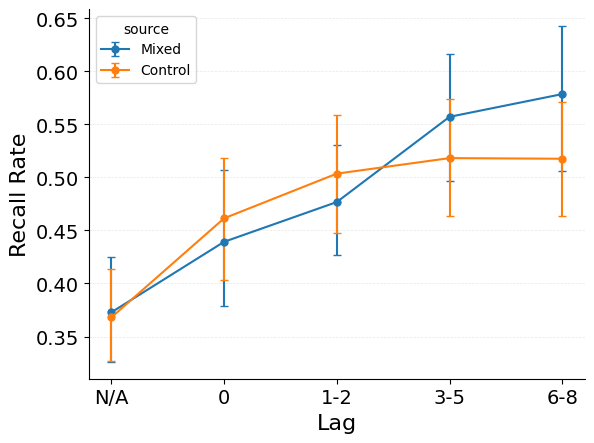

In [4]:

plotting_function(
    datasets, 
    masks, 
    labels=["Mixed", "Control"], 
    contrast_name="source"
);
